# 🚀 [실습] MFU 개선 프로젝트 수행

## 프로젝트 개요
이 실습에서는 딥러닝 모델의 MFU (Model FLOPs Utilization)를 측정하고 개선하는 과정을 단계별로 진행합니다.

### 프로젝트 단계
1. **모델 선정**: 최적화 대상 모델 선택 (CNN, Transformer, Custom 모델)
2. **베이스라인 측정**: 최적화 전 성능 프로파일링 및 MFU 수치 기록
3. **병목 분석**: PyTorch Profiler로 병목 레이어 및 연산 식별
4. **최적화 적용**: Fusion, Quantization 등의 기법 적용
5. **결과 분석**: 최적화 전/후 MFU 비교 및 성능 향상 측정

### 평가 기준
- 🏆 **우수**: MFU 20% 이상 향상
- ✅ **양호**: MFU 10-20% 향상
- 📌 **기본**: MFU 5% 이상 향상

## 📋 1단계: 환경 설정 및 라이브러리 임포트

In [1]:
# GPU 확인
!nvidia-smi

Wed Oct 22 17:01:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 필요한 라이브러리 설치
!pip install torch torchvision timm matplotlib seaborn pandas -q
!pip install torch-tb-profiler -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.3 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.profiler import profile, ProfilerActivity, record_function
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 시드 설정
torch.manual_seed(42)
np.random.seed(42)

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB


## 🎯 2단계: 모델 선정

### Colab 친화적 모델 옵션

#### 초급 모델 (메모리: ~2-4GB)
- ResNet18/50: 컴퓨터 비전 기본 모델
- MobileNetV2: 경량화 모델

#### 중급 모델 (메모리: ~4-8GB)
- BERT-small: NLP Transformer 모델
- ViT-tiny: Vision Transformer

#### 고급 모델 (메모리: ~8-12GB)
- EfficientNet: 효율적인 CNN
- YOLOv5-small: 객체 탐지 모델

**💡 고려사항**
- Colab GPU 메모리 제한: 12-16GB
- 세션 유지 시간: 12시간 한도
- 대형 모델은 체크포인트 저장 필수

In [4]:
# 모델 선택 (원하는 모델의 주석을 해제하세요)

# 초급: ResNet18
model_name = "ResNet18"
model = models.resnet18(pretrained=False)
input_shape = (1, 3, 224, 224)
theoretical_flops = 1.814e9  # 약 1.8 GFLOPs

# 초급: MobileNetV2
# model_name = "MobileNetV2"
# model = models.mobilenet_v2(pretrained=False)
# input_shape = (1, 3, 224, 224)
# theoretical_flops = 0.3e9  # 약 0.3 GFLOPs

# 중급: ResNet50
# model_name = "ResNet50"
# model = models.resnet50(pretrained=False)
# input_shape = (1, 3, 224, 224)
# theoretical_flops = 4.089e9  # 약 4.1 GFLOPs

# 고급: EfficientNet-B0 (timm 필요)
# import timm
# model_name = "EfficientNet-B0"
# model = timm.create_model('efficientnet_b0', pretrained=False)
# input_shape = (1, 3, 224, 224)
# theoretical_flops = 0.39e9  # 약 0.39 GFLOPs

model = model.to(device)
model.eval()

print(f"\n선택된 모델: {model_name}")
print(f"입력 shape: {input_shape}")
print(f"이론적 FLOPs: {theoretical_flops/1e9:.2f} GFLOPs")

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")


선택된 모델: ResNet18
입력 shape: (1, 3, 224, 224)
이론적 FLOPs: 1.81 GFLOPs
전체 파라미터: 11,689,512
학습 가능 파라미터: 11,689,512


## 📊 3단계: 베이스라인 MFU 측정

MFU (Model FLOPs Utilization) = (실제 달성 FLOPs / 하드웨어 최대 FLOPs) × 100%

In [5]:
def get_gpu_peak_flops(device_name: str) -> float:
    """
    GPU의 이론적 최대 FP32 FLOPs를 반환합니다.
    """
    # 일반적인 GPU의 FP32 성능 (TFLOPs)
    gpu_specs = {
        'T4': 8.1,        # Tesla T4
        'P100': 9.3,      # Tesla P100
        'V100': 15.7,     # Tesla V100
        'A100': 19.5,     # A100 (FP32)
        'RTX': 10.0,      # 일반 RTX 계열
    }

    for key, value in gpu_specs.items():
        if key in device_name:
            return value * 1e12  # TFLOPs to FLOPs

    # 기본값 (Colab T4 기준)
    return 8.1e12

def measure_baseline_performance(model, input_shape, num_iterations=100, warmup=10):
    """
    베이스라인 성능을 측정합니다.
    """
    model.eval()

    # 더미 입력 생성
    dummy_input = torch.randn(*input_shape).to(device)

    # Warmup
    print("Warming up...")
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)

    # CUDA 동기화
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # 실제 측정
    print(f"Measuring performance over {num_iterations} iterations...")
    inference_times = []

    with torch.no_grad():
        for i in range(num_iterations):
            start = time.time()
            _ = model(dummy_input)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            end = time.time()
            inference_times.append(end - start)

    # 통계 계산
    avg_time = np.mean(inference_times)
    std_time = np.std(inference_times)
    min_time = np.min(inference_times)
    max_time = np.max(inference_times)

    # FLOPs 계산
    achieved_flops = theoretical_flops / avg_time

    # GPU 최대 FLOPs
    device_name = torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'
    peak_flops = get_gpu_peak_flops(device_name)

    # MFU 계산
    mfu = (achieved_flops / peak_flops) * 100

    results = {
        'avg_time_ms': avg_time * 1000,
        'std_time_ms': std_time * 1000,
        'min_time_ms': min_time * 1000,
        'max_time_ms': max_time * 1000,
        'throughput_fps': 1.0 / avg_time,
        'achieved_flops': achieved_flops,
        'peak_flops': peak_flops,
        'mfu_percent': mfu,
        'device_name': device_name
    }

    return results, inference_times

def print_performance_report(results: Dict, title: str = "Performance Report"):
    """
    성능 측정 결과를 출력합니다.
    """
    print(f"\n{'='*60}")
    print(f"{title:^60}")
    print(f"{'='*60}")
    print(f"Device: {results['device_name']}")
    print(f"\n[Latency]")
    print(f"  Average: {results['avg_time_ms']:.2f} ms (±{results['std_time_ms']:.2f})")
    print(f"  Min: {results['min_time_ms']:.2f} ms")
    print(f"  Max: {results['max_time_ms']:.2f} ms")
    print(f"\n[Throughput]")
    print(f"  FPS: {results['throughput_fps']:.2f}")
    print(f"\n[FLOPs Utilization]")
    print(f"  Achieved FLOPs: {results['achieved_flops']/1e12:.2f} TFLOPs")
    print(f"  Peak FLOPs: {results['peak_flops']/1e12:.2f} TFLOPs")
    print(f"  MFU: {results['mfu_percent']:.2f}%")
    print(f"{'='*60}\n")

# 베이스라인 측정 실행
baseline_results, baseline_times = measure_baseline_performance(model, input_shape)
print_performance_report(baseline_results, "🔍 BASELINE Performance")

Warming up...
Measuring performance over 100 iterations...

                   🔍 BASELINE Performance                   
Device: Tesla T4

[Latency]
  Average: 3.28 ms (±0.73)
  Min: 2.41 ms
  Max: 4.69 ms

[Throughput]
  FPS: 304.71

[FLOPs Utilization]
  Achieved FLOPs: 0.55 TFLOPs
  Peak FLOPs: 8.10 TFLOPs
  MFU: 6.82%



## 🔬 4단계: 병목 분석 (PyTorch Profiler)

PyTorch Profiler를 사용하여 모델의 병목 지점을 식별합니다.

In [6]:
def profile_model(model, input_shape, num_iterations=10):
    """
    PyTorch Profiler를 사용하여 모델을 프로파일링합니다.
    """
    model.eval()
    dummy_input = torch.randn(*input_shape).to(device)

    # Profiler 설정
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
        with_stack=True
    ) as prof:
        with record_function("model_inference"):
            for _ in range(num_iterations):
                with torch.no_grad():
                    _ = model(dummy_input)

    return prof

# 프로파일링 실행
print("Profiling model...")
prof = profile_model(model, input_shape)

# 결과 출력: CPU 시간 기준 상위 10개
print("\n[Top 10 operations by CPU time]")
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))

# 결과 출력: CUDA 시간 기준 상위 10개
if device.type == 'cuda':
    print("\n[Top 10 operations by CUDA time]")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

Profiling model...

[Top 10 operations by CPU time]
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference        34.79%      23.393ms        99.98%      67.221ms      67.221ms       0.000us         0.00%      37.952ms      37.952ms   

In [7]:
# 메모리 사용량 분석
if device.type == 'cuda':
    print("\n[Top 10 operations by memory usage]")
    print(prof.key_averages().table(sort_by="self_cuda_memory_usage", row_limit=10))


[Top 10 operations by memory usage]
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                aten::cudnn_convolution        10.74%       7.223ms        19.02%      12.785ms      63.926us      34.281ms        90.65%      34.416ms     172.082us           0 B    

## ⚡ 5단계: 최적화 적용

### 최적화 기법
1. **Operator Fusion**: 연산 결합으로 메모리 접근 감소
2. **Quantization**: INT8 양자화로 연산 속도 향상
3. **Mixed Precision**: FP16 사용으로 메모리 및 속도 개선
4. **Compilation**: TorchScript/TorchInductor로 그래프 최적화

### 5-1. TorchScript 최적화 (Operator Fusion)

In [8]:
# TorchScript로 변환 (JIT compilation)
dummy_input = torch.randn(*input_shape).to(device)

print("Converting to TorchScript...")
scripted_model = torch.jit.trace(model, dummy_input)
scripted_model = torch.jit.optimize_for_inference(scripted_model)

# TorchScript 모델 성능 측정
scripted_results, scripted_times = measure_baseline_performance(
    scripted_model, input_shape
)
print_performance_report(scripted_results, "⚡ TorchScript Optimized")

# 개선율 계산
speedup = baseline_results['avg_time_ms'] / scripted_results['avg_time_ms']
mfu_improvement = scripted_results['mfu_percent'] - baseline_results['mfu_percent']
print(f"Speedup: {speedup:.2f}x")
print(f"MFU Improvement: {mfu_improvement:+.2f}%")

Converting to TorchScript...
Warming up...
Measuring performance over 100 iterations...

                  ⚡ TorchScript Optimized                   
Device: Tesla T4

[Latency]
  Average: 7.81 ms (±3.76)
  Min: 2.63 ms
  Max: 21.00 ms

[Throughput]
  FPS: 127.98

[FLOPs Utilization]
  Achieved FLOPs: 0.23 TFLOPs
  Peak FLOPs: 8.10 TFLOPs
  MFU: 2.87%

Speedup: 0.42x
MFU Improvement: -3.96%


### 5-2. Dynamic Quantization (INT8)

In [9]:
# CPU에서만 동작하는 Dynamic Quantization
# GPU 지원을 위해서는 Static Quantization이 필요

if device.type == 'cpu':
    print("Applying dynamic quantization...")
    quantized_model = torch.quantization.quantize_dynamic(
        model.cpu(),
        {nn.Linear, nn.Conv2d},
        dtype=torch.qint8
    )

    # Quantized 모델 성능 측정
    quantized_results, quantized_times = measure_baseline_performance(
        quantized_model, input_shape
    )
    print_performance_report(quantized_results, "🔢 Quantized (INT8)")

    # 개선율
    speedup = baseline_results['avg_time_ms'] / quantized_results['avg_time_ms']
    mfu_improvement = quantized_results['mfu_percent'] - baseline_results['mfu_percent']
    print(f"Speedup: {speedup:.2f}x")
    print(f"MFU Improvement: {mfu_improvement:+.2f}%")

    # 모델 크기 비교
    import os
    torch.save(model.state_dict(), '/tmp/baseline_model.pth')
    torch.save(quantized_model.state_dict(), '/tmp/quantized_model.pth')
    baseline_size = os.path.getsize('/tmp/baseline_model.pth') / 1e6
    quantized_size = os.path.getsize('/tmp/quantized_model.pth') / 1e6
    print(f"\nModel size reduction: {baseline_size:.2f} MB -> {quantized_size:.2f} MB ({quantized_size/baseline_size*100:.1f}%)")
else:
    print("⚠️  Dynamic quantization is only supported on CPU.")
    print("For GPU inference, use TensorRT or ONNX Runtime with static quantization.")

⚠️  Dynamic quantization is only supported on CPU.
For GPU inference, use TensorRT or ONNX Runtime with static quantization.


### 5-3. Mixed Precision (FP16) with Automatic Mixed Precision (AMP)

In [10]:
if device.type == 'cuda':
    print("Testing Mixed Precision (FP16)...")

    def measure_amp_performance(model, input_shape, num_iterations=100, warmup=10):
        """
        AMP를 사용한 성능 측정
        """
        model.eval()
        dummy_input = torch.randn(*input_shape).to(device)

        # Warmup
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                for _ in range(warmup):
                    _ = model(dummy_input)

        torch.cuda.synchronize()

        # 측정
        inference_times = []
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                for _ in range(num_iterations):
                    start = time.time()
                    _ = model(dummy_input)
                    torch.cuda.synchronize()
                    end = time.time()
                    inference_times.append(end - start)

        avg_time = np.mean(inference_times)
        achieved_flops = theoretical_flops / avg_time
        device_name = torch.cuda.get_device_name(0)
        peak_flops = get_gpu_peak_flops(device_name)
        mfu = (achieved_flops / peak_flops) * 100

        return {
            'avg_time_ms': avg_time * 1000,
            'std_time_ms': np.std(inference_times) * 1000,
            'min_time_ms': np.min(inference_times) * 1000,
            'max_time_ms': np.max(inference_times) * 1000,
            'throughput_fps': 1.0 / avg_time,
            'achieved_flops': achieved_flops,
            'peak_flops': peak_flops,
            'mfu_percent': mfu,
            'device_name': device_name
        }, inference_times

    amp_results, amp_times = measure_amp_performance(model, input_shape)
    print_performance_report(amp_results, "🚀 Mixed Precision (FP16)")

    # 개선율
    speedup = baseline_results['avg_time_ms'] / amp_results['avg_time_ms']
    mfu_improvement = amp_results['mfu_percent'] - baseline_results['mfu_percent']
    print(f"Speedup: {speedup:.2f}x")
    print(f"MFU Improvement: {mfu_improvement:+.2f}%")
else:
    print("⚠️  Mixed precision requires CUDA GPU.")

Testing Mixed Precision (FP16)...

                  🚀 Mixed Precision (FP16)                  
Device: Tesla T4

[Latency]
  Average: 3.27 ms (±0.30)
  Min: 2.95 ms
  Max: 4.41 ms

[Throughput]
  FPS: 305.80

[FLOPs Utilization]
  Achieved FLOPs: 0.55 TFLOPs
  Peak FLOPs: 8.10 TFLOPs
  MFU: 6.85%

Speedup: 1.00x
MFU Improvement: +0.02%


### 5-4. Channels Last Memory Format (메모리 레이아웃 최적화)

In [11]:
if device.type == 'cuda':
    print("Testing Channels Last memory format...")

    # 모델을 channels_last로 변환
    model_channels_last = model.to(memory_format=torch.channels_last)

    # 입력도 channels_last로 변환해야 함
    def measure_channels_last_performance(model, input_shape, num_iterations=100, warmup=10):
        model.eval()
        dummy_input = torch.randn(*input_shape).to(device).to(memory_format=torch.channels_last)

        # Warmup
        with torch.no_grad():
            for _ in range(warmup):
                _ = model(dummy_input)

        torch.cuda.synchronize()

        # 측정
        inference_times = []
        with torch.no_grad():
            for _ in range(num_iterations):
                start = time.time()
                _ = model(dummy_input)
                torch.cuda.synchronize()
                end = time.time()
                inference_times.append(end - start)

        avg_time = np.mean(inference_times)
        achieved_flops = theoretical_flops / avg_time
        device_name = torch.cuda.get_device_name(0)
        peak_flops = get_gpu_peak_flops(device_name)
        mfu = (achieved_flops / peak_flops) * 100

        return {
            'avg_time_ms': avg_time * 1000,
            'std_time_ms': np.std(inference_times) * 1000,
            'min_time_ms': np.min(inference_times) * 1000,
            'max_time_ms': np.max(inference_times) * 1000,
            'throughput_fps': 1.0 / avg_time,
            'achieved_flops': achieved_flops,
            'peak_flops': peak_flops,
            'mfu_percent': mfu,
            'device_name': device_name
        }, inference_times

    channels_last_results, channels_last_times = measure_channels_last_performance(
        model_channels_last, input_shape
    )
    print_performance_report(channels_last_results, "💾 Channels Last Memory Format")

    # 개선율
    speedup = baseline_results['avg_time_ms'] / channels_last_results['avg_time_ms']
    mfu_improvement = channels_last_results['mfu_percent'] - baseline_results['mfu_percent']
    print(f"Speedup: {speedup:.2f}x")
    print(f"MFU Improvement: {mfu_improvement:+.2f}%")
else:
    print("⚠️  Channels last optimization is most effective on CUDA.")

Testing Channels Last memory format...

               💾 Channels Last Memory Format                
Device: Tesla T4

[Latency]
  Average: 4.49 ms (±1.13)
  Min: 3.36 ms
  Max: 8.62 ms

[Throughput]
  FPS: 222.88

[FLOPs Utilization]
  Achieved FLOPs: 0.40 TFLOPs
  Peak FLOPs: 8.10 TFLOPs
  MFU: 4.99%

Speedup: 0.73x
MFU Improvement: -1.83%


### 5-5. 통합 최적화 (TorchScript + AMP + Channels Last)

In [12]:
if device.type == 'cuda':
    print("Testing combined optimizations...")

    # 모델 준비
    combined_model = model.to(memory_format=torch.channels_last)
    dummy_input_cl = torch.randn(*input_shape).to(device).to(memory_format=torch.channels_last)

    # TorchScript 변환
    combined_model = torch.jit.trace(combined_model, dummy_input_cl)
    combined_model = torch.jit.optimize_for_inference(combined_model)

    def measure_combined_performance(model, input_shape, num_iterations=100, warmup=10):
        model.eval()
        dummy_input = torch.randn(*input_shape).to(device).to(memory_format=torch.channels_last)

        # Warmup
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                for _ in range(warmup):
                    _ = model(dummy_input)

        torch.cuda.synchronize()

        # 측정
        inference_times = []
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                for _ in range(num_iterations):
                    start = time.time()
                    _ = model(dummy_input)
                    torch.cuda.synchronize()
                    end = time.time()
                    inference_times.append(end - start)

        avg_time = np.mean(inference_times)
        achieved_flops = theoretical_flops / avg_time
        device_name = torch.cuda.get_device_name(0)
        peak_flops = get_gpu_peak_flops(device_name)
        mfu = (achieved_flops / peak_flops) * 100

        return {
            'avg_time_ms': avg_time * 1000,
            'std_time_ms': np.std(inference_times) * 1000,
            'min_time_ms': np.min(inference_times) * 1000,
            'max_time_ms': np.max(inference_times) * 1000,
            'throughput_fps': 1.0 / avg_time,
            'achieved_flops': achieved_flops,
            'peak_flops': peak_flops,
            'mfu_percent': mfu,
            'device_name': device_name
        }, inference_times

    combined_results, combined_times = measure_combined_performance(
        combined_model, input_shape
    )
    print_performance_report(combined_results, "🎯 COMBINED Optimizations")

    # 개선율
    speedup = baseline_results['avg_time_ms'] / combined_results['avg_time_ms']
    mfu_improvement = combined_results['mfu_percent'] - baseline_results['mfu_percent']
    print(f"Total Speedup: {speedup:.2f}x")
    print(f"Total MFU Improvement: {mfu_improvement:+.2f}%")
else:
    print("⚠️  Combined optimizations require CUDA GPU.")

Testing combined optimizations...

                  🎯 COMBINED Optimizations                  
Device: Tesla T4

[Latency]
  Average: 1.37 ms (±0.02)
  Min: 1.36 ms
  Max: 1.52 ms

[Throughput]
  FPS: 727.87

[FLOPs Utilization]
  Achieved FLOPs: 1.32 TFLOPs
  Peak FLOPs: 8.10 TFLOPs
  MFU: 16.30%

Total Speedup: 2.39x
Total MFU Improvement: +9.48%


## 📈 6단계: 결과 분석 및 시각화

In [13]:
# 결과 수집
optimization_results = {
    'Baseline': baseline_results,
    'TorchScript': scripted_results,
}

if device.type == 'cuda':
    optimization_results['Mixed Precision'] = amp_results
    optimization_results['Channels Last'] = channels_last_results
    optimization_results['Combined'] = combined_results
elif device.type == 'cpu':
    optimization_results['Quantized'] = quantized_results

# 비교 테이블 생성
import pandas as pd

comparison_data = {
    'Optimization': [],
    'Latency (ms)': [],
    'Throughput (FPS)': [],
    'MFU (%)': [],
    'Speedup': [],
    'MFU Improvement (%)': []
}

baseline_time = baseline_results['avg_time_ms']
baseline_mfu = baseline_results['mfu_percent']

for name, result in optimization_results.items():
    comparison_data['Optimization'].append(name)
    comparison_data['Latency (ms)'].append(f"{result['avg_time_ms']:.2f}")
    comparison_data['Throughput (FPS)'].append(f"{result['throughput_fps']:.2f}")
    comparison_data['MFU (%)'].append(f"{result['mfu_percent']:.2f}")

    speedup = baseline_time / result['avg_time_ms']
    mfu_diff = result['mfu_percent'] - baseline_mfu

    comparison_data['Speedup'].append(f"{speedup:.2f}x")
    comparison_data['MFU Improvement (%)'].append(f"{mfu_diff:+.2f}")

df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("OPTIMIZATION COMPARISON TABLE")
print("="*80)
print(df.to_string(index=False))
print("="*80)


OPTIMIZATION COMPARISON TABLE
   Optimization Latency (ms) Throughput (FPS) MFU (%) Speedup MFU Improvement (%)
       Baseline         3.28           304.71    6.82   1.00x               +0.00
    TorchScript         7.81           127.98    2.87   0.42x               -3.96
Mixed Precision         3.27           305.80    6.85   1.00x               +0.02
  Channels Last         4.49           222.88    4.99   0.73x               -1.83
       Combined         1.37           727.87   16.30   2.39x               +9.48


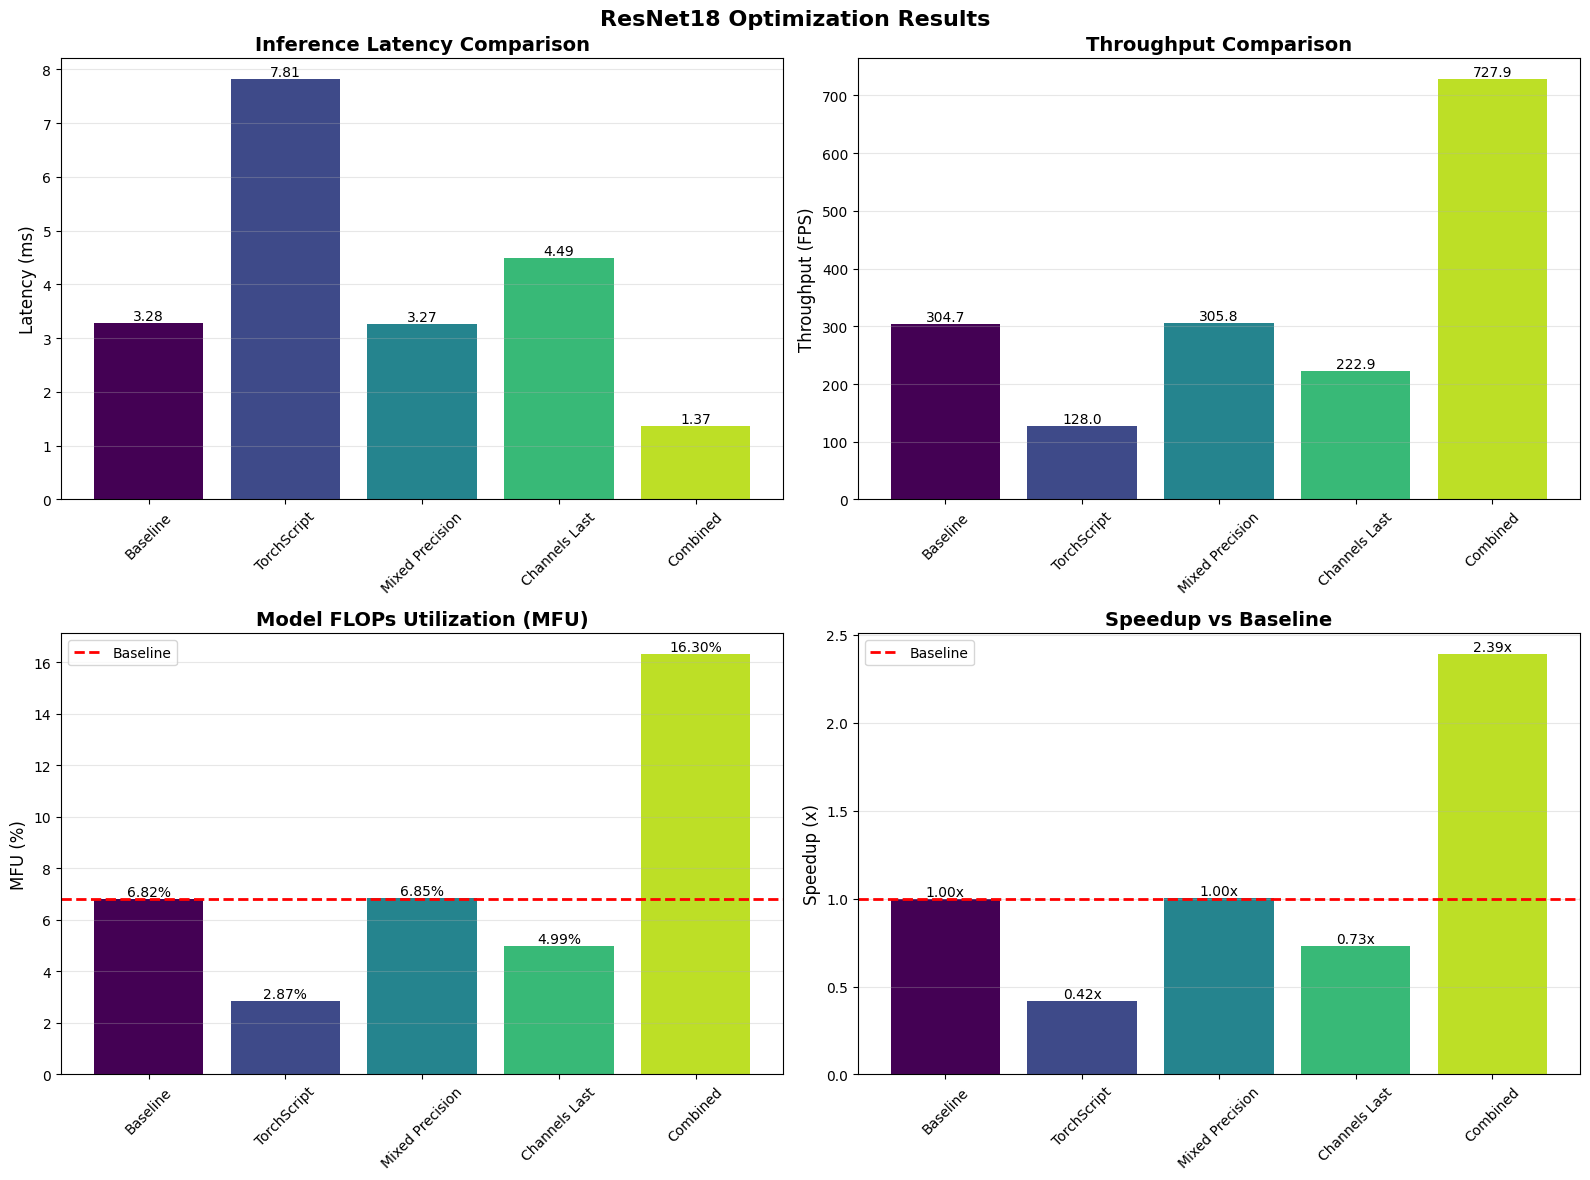


📊 Visualization saved to 'optimization_results.png'


In [14]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{model_name} Optimization Results', fontsize=16, fontweight='bold')

opt_names = list(optimization_results.keys())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(opt_names)))

# 1. Latency 비교
ax = axes[0, 0]
latencies = [optimization_results[name]['avg_time_ms'] for name in opt_names]
bars = ax.bar(opt_names, latencies, color=colors)
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Inference Latency Comparison', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=10)

# 2. Throughput 비교
ax = axes[0, 1]
throughputs = [optimization_results[name]['throughput_fps'] for name in opt_names]
bars = ax.bar(opt_names, throughputs, color=colors)
ax.set_ylabel('Throughput (FPS)', fontsize=12)
ax.set_title('Throughput Comparison', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=10)

# 3. MFU 비교
ax = axes[1, 0]
mfus = [optimization_results[name]['mfu_percent'] for name in opt_names]
bars = ax.bar(opt_names, mfus, color=colors)
ax.set_ylabel('MFU (%)', fontsize=12)
ax.set_title('Model FLOPs Utilization (MFU)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=baseline_mfu, color='r', linestyle='--', label='Baseline', linewidth=2)
ax.legend()

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

# 4. Speedup 비교
ax = axes[1, 1]
speedups = [baseline_time / optimization_results[name]['avg_time_ms'] for name in opt_names]
bars = ax.bar(opt_names, speedups, color=colors)
ax.set_ylabel('Speedup (x)', fontsize=12)
ax.set_title('Speedup vs Baseline', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='r', linestyle='--', label='Baseline', linewidth=2)
ax.legend()

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}x',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved to 'optimization_results.png'")

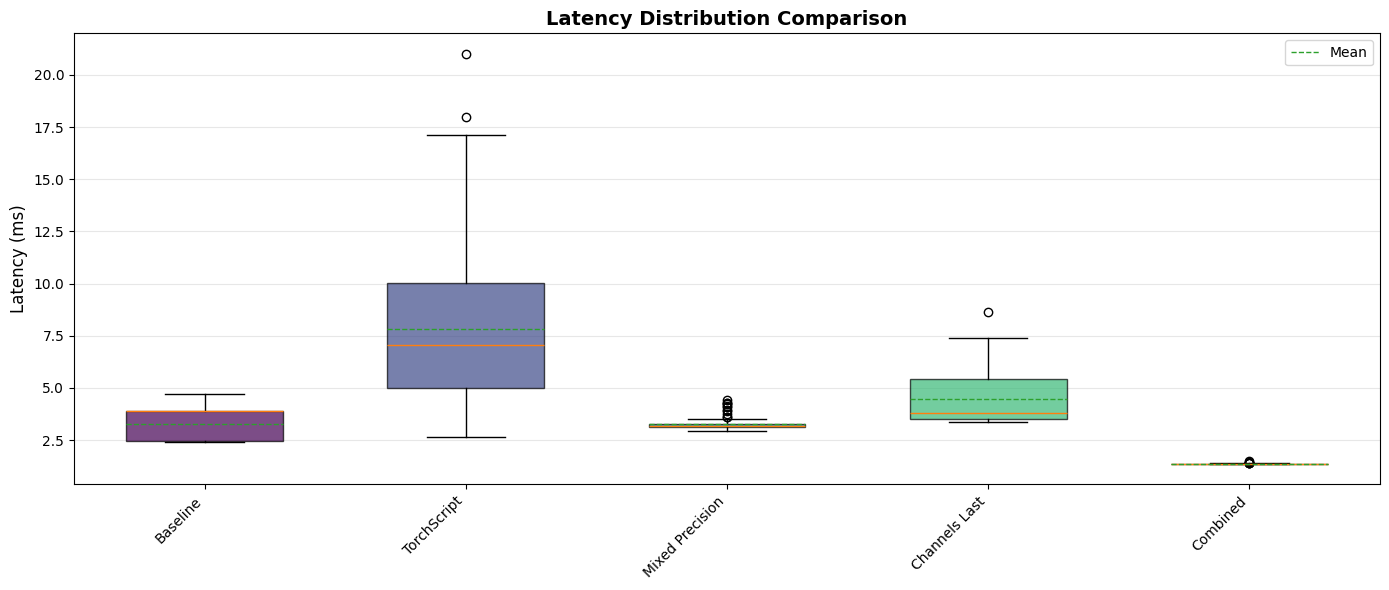


📊 Latency distribution saved to 'latency_distribution.png'


In [15]:
# Latency 분포 비교
fig, ax = plt.subplots(figsize=(14, 6))

all_times = {
    'Baseline': baseline_times,
    'TorchScript': scripted_times,
}

if device.type == 'cuda':
    all_times['Mixed Precision'] = amp_times
    all_times['Channels Last'] = channels_last_times
    all_times['Combined'] = combined_times
elif device.type == 'cpu':
    all_times['Quantized'] = quantized_times

positions = range(len(all_times))
box_data = [np.array(times) * 1000 for times in all_times.values()]  # Convert to ms

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=True)

# 색상 적용
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(all_times.keys(), rotation=45, ha='right')
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Latency Distribution Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend([bp['means'][0]], ['Mean'], loc='upper right')

plt.tight_layout()
plt.savefig('/tmp/latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Latency distribution saved to 'latency_distribution.png'")

## 📝 7단계: 최종 보고서 생성

In [16]:
# 최종 결과 요약
final_opt_name = list(optimization_results.keys())[-1]  # 마지막 최적화 (보통 Combined)
final_results = optimization_results[final_opt_name]

final_speedup = baseline_time / final_results['avg_time_ms']
final_mfu_improvement = final_results['mfu_percent'] - baseline_mfu

report = f"""
{'='*80}
                    MFU OPTIMIZATION PROJECT - FINAL REPORT
{'='*80}

📌 PROJECT INFORMATION
Model: {model_name}
Device: {baseline_results['device_name']}
Input Shape: {input_shape}
Theoretical FLOPs: {theoretical_flops/1e9:.2f} GFLOPs

{'='*80}
📊 BASELINE PERFORMANCE
{'='*80}
Latency: {baseline_results['avg_time_ms']:.2f} ms
Throughput: {baseline_results['throughput_fps']:.2f} FPS
MFU: {baseline_results['mfu_percent']:.2f}%
Achieved FLOPs: {baseline_results['achieved_flops']/1e12:.2f} TFLOPs

{'='*80}
⚡ OPTIMIZED PERFORMANCE ({final_opt_name})
{'='*80}
Latency: {final_results['avg_time_ms']:.2f} ms ({(1-final_results['avg_time_ms']/baseline_time)*100:.1f}% reduction)
Throughput: {final_results['throughput_fps']:.2f} FPS ({(final_results['throughput_fps']/baseline_results['throughput_fps']-1)*100:.1f}% increase)
MFU: {final_results['mfu_percent']:.2f}% ({final_mfu_improvement:+.2f}% improvement)
Achieved FLOPs: {final_results['achieved_flops']/1e12:.2f} TFLOPs

{'='*80}
🎯 OVERALL IMPROVEMENT
{'='*80}
Speedup: {final_speedup:.2f}x
MFU Improvement: {final_mfu_improvement:+.2f}%
Performance Gain: {(final_speedup-1)*100:.1f}%

{'='*80}
📋 APPLIED OPTIMIZATIONS
{'='*80}
"""

opt_count = 1
for opt_name in optimization_results.keys():
    if opt_name != 'Baseline':
        result = optimization_results[opt_name]
        speedup = baseline_time / result['avg_time_ms']
        mfu_diff = result['mfu_percent'] - baseline_mfu
        report += f"{opt_count}. {opt_name}\n"
        report += f"   - Speedup: {speedup:.2f}x\n"
        report += f"   - MFU Improvement: {mfu_diff:+.2f}%\n"
        report += f"   - Latency: {result['avg_time_ms']:.2f} ms\n\n"
        opt_count += 1

report += f"""{'='*80}
✅ EVALUATION CRITERIA
{'='*80}
"""

if final_mfu_improvement >= 20:
    grade = "🏆 EXCELLENT (우수)"
    comment = "Outstanding MFU improvement! You've achieved significant optimization."
elif final_mfu_improvement >= 10:
    grade = "✅ GOOD (양호)"
    comment = "Good MFU improvement. Consider exploring additional optimization techniques."
elif final_mfu_improvement >= 5:
    grade = "📌 BASIC (기본)"
    comment = "Basic MFU improvement achieved. Try combining multiple optimization methods."
else:
    grade = "⚠️  NEEDS IMPROVEMENT"
    comment = "Limited improvement. Review profiling results and try different optimization strategies."

report += f"""
Final Grade: {grade}
MFU Improvement: {final_mfu_improvement:+.2f}%
Comment: {comment}

{'='*80}
💡 RECOMMENDATIONS
{'='*80}
"""

if final_mfu_improvement < 10:
    report += """
1. Review the profiling results to identify major bottlenecks
2. Consider using TensorRT or ONNX Runtime for production deployment
3. Experiment with batch size optimization
4. Try different memory layouts (channels_last)
5. Consider model architecture modifications (pruning, distillation)
"""
elif final_mfu_improvement < 20:
    report += """
1. Your optimizations are working well!
2. Consider deploying with TensorRT for even better performance
3. Monitor memory usage and try to reduce peak memory consumption
4. Experiment with static quantization for production
"""
else:
    report += """
1. Excellent work on optimization!
2. Consider this as a baseline for production deployment
3. Document your optimization pipeline for reproducibility
4. Monitor real-world performance with actual data
"""

report += f"\n{'='*80}\n"

print(report)

# 보고서 저장
with open('/tmp/optimization_report.txt', 'w') as f:
    f.write(report)

print("\n📄 Final report saved to 'optimization_report.txt'")


                    MFU OPTIMIZATION PROJECT - FINAL REPORT

📌 PROJECT INFORMATION
Model: ResNet18
Device: Tesla T4
Input Shape: (1, 3, 224, 224)
Theoretical FLOPs: 1.81 GFLOPs

📊 BASELINE PERFORMANCE
Latency: 3.28 ms
Throughput: 304.71 FPS
MFU: 6.82%
Achieved FLOPs: 0.55 TFLOPs

⚡ OPTIMIZED PERFORMANCE (Combined)
Latency: 1.37 ms (58.1% reduction)
Throughput: 727.87 FPS (138.9% increase)
MFU: 16.30% (+9.48% improvement)
Achieved FLOPs: 1.32 TFLOPs

🎯 OVERALL IMPROVEMENT
Speedup: 2.39x
MFU Improvement: +9.48%
Performance Gain: 138.9%

📋 APPLIED OPTIMIZATIONS
1. TorchScript
   - Speedup: 0.42x
   - MFU Improvement: -3.96%
   - Latency: 7.81 ms

2. Mixed Precision
   - Speedup: 1.00x
   - MFU Improvement: +0.02%
   - Latency: 3.27 ms

3. Channels Last
   - Speedup: 0.73x
   - MFU Improvement: -1.83%
   - Latency: 4.49 ms

4. Combined
   - Speedup: 2.39x
   - MFU Improvement: +9.48%
   - Latency: 1.37 ms

✅ EVALUATION CRITERIA

Final Grade: 📌 BASIC (기본)
MFU Improvement: +9.48%
Comment: B

## 🎓 추가 학습 자료

### PyTorch 최적화 관련 문서
- [PyTorch Performance Tuning Guide](https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html)
- [TorchScript](https://pytorch.org/docs/stable/jit.html)
- [Quantization](https://pytorch.org/docs/stable/quantization.html)
- [Automatic Mixed Precision](https://pytorch.org/docs/stable/amp.html)
- [Profiler](https://pytorch.org/tutorials/recipes/recipes/profiler_recipe.html)

### 추가 최적화 기법
1. **Model Pruning**: 불필요한 연결 제거
2. **Knowledge Distillation**: 큰 모델의 지식을 작은 모델로 전달
3. **Neural Architecture Search**: 최적의 아키텍처 자동 탐색
4. **TensorRT**: NVIDIA의 고성능 추론 엔진
5. **ONNX Runtime**: 크로스 플랫폼 추론 최적화

### 실무 팁
- 프로파일링을 통해 병목 지점을 먼저 식별하세요
- 한 번에 하나의 최적화만 적용하여 효과를 측정하세요
- 정확도와 성능의 트레이드오프를 고려하세요
- 실제 데이터로 검증하세요

## 💾 체크포인트 저장 (선택사항)

최적화된 모델을 저장하여 나중에 사용할 수 있습니다.

In [17]:
# 최적화된 모델 저장
import os

checkpoint_dir = '/tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# TorchScript 모델 저장
scripted_model.save(f'{checkpoint_dir}/{model_name}_optimized.pt')
print(f"✅ Optimized model saved to '{checkpoint_dir}/{model_name}_optimized.pt'")

# 메타데이터 저장
metadata = {
    'model_name': model_name,
    'input_shape': input_shape,
    'baseline_mfu': baseline_mfu,
    'optimized_mfu': final_results['mfu_percent'],
    'mfu_improvement': final_mfu_improvement,
    'speedup': final_speedup,
    'device': baseline_results['device_name'],
}

import json
with open(f'{checkpoint_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved to '{checkpoint_dir}/metadata.json'")

✅ Optimized model saved to '/tmp/checkpoints/ResNet18_optimized.pt'
✅ Metadata saved to '/tmp/checkpoints/metadata.json'


## 🎉 축하합니다!

MFU 개선 프로젝트를 완료했습니다! 다음 단계를 고려해보세요:

1. **다른 모델로 실험**: 다양한 모델 아키텍처에 최적화를 적용해보세요
2. **배치 크기 최적화**: 다양한 배치 크기로 실험하여 최적의 throughput을 찾으세요
3. **프로덕션 배포**: TensorRT나 ONNX Runtime으로 더 나은 성능을 달성하세요
4. **정확도 검증**: 최적화 후에도 모델의 정확도가 유지되는지 확인하세요

**질문이 있으시면 언제든지 물어보세요! 🚀**